# PCOS detection - comparing a classic CV pipeline with a simple CNN

Polycystic Ovarian Syndrome (PCOS) is a disease that affects an estimated 15% of women worldwide. As of today, it requires a multi-modal diagnostic process and often symptoms are dismissed. One portion of the diagnostic is made via the classification of uterine ultrasound images, which requires the time and expertise of at least two medical professionals. The ultrasound images of PCOS infected uteruses are quite distinct and easily diagnosible, but they still take time and attention. Radiologists which look over these images are trained professionals and qualified for much less obvious visual diagnosis, thus, this project aims to provide two models which could potentially be used to classify ultrasound images as PCOS infected vs. healthy, reducing the work load of medical professionals which are currently facing a worker shortage.

In [466]:
# imports
# data
import kagglehub

# system
import os
from pathlib import Path

# processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import itertools
import PIL
from PIL import Image
from torch.utils.data import Subset, ConcatDataset
from typing import Tuple, List, Optional
import seaborn as sns

# models
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import optuna
import tqdm
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

In [406]:
sns.set_theme(style="white", palette="pastel")
sns.set_context("notebook", font_scale=1.2)

## Preprocess data

In [4]:
# download data
path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images", force_download=False)

In [5]:
def valid(path):
        try:
            filename = os.path.basename(path)
            if not filename.lower().startswith("img"):
                return False
            with Image.open(path) as img:
                img.verify()
            return True
        except Exception:
            return False


In [6]:
for p in Path(path).rglob('*'):
    if p.is_file():
        ok = valid(str(p))
        if not ok:
            print(f"Deleting: {p.name}")
            p.unlink()

In [ ]:
class Prep:
    def __init__(self, path: str, output_size=224) -> None:
        self.path = path

        actual_root = None
        for root, dirs, files in os.walk(path):
            if 'train' in dirs and 'test' in dirs:
                actual_root = root
                break
        
        if not actual_root:
            raise FileNotFoundError(f"Could not find 'train/test' in {path}")

        self.output_size = output_size

        self.train_path = os.path.join(actual_root, "train")
        #self.test_path = os.path.join(actual_root, "test")

        self.cnn = self.import_data_cnn()
        self.cv = self.import_data_cv()

        self.train_cv, self.test_cv, self.val_cv = self.split_data(self.cv)
        self.train_cnn, self.test_cnn, self.val_cnn = self.split_data(self.cnn)

    def split_data(self, dataset, class_split_at=780) -> None:

        infected = Subset(dataset, list(range(class_split_at)))
        healthy = Subset(dataset, list(range(class_split_at, len(dataset))))

        full_dataset = ConcatDataset([infected, healthy])

        n_infected = len(infected)
        n_healthy = len(healthy)

        train_idx = list(range(0, int(0.8 * n_infected))) + list(range(n_infected, n_infected + int(0.8 * n_healthy)))
        val_idx   = list(range(int(0.8 * n_infected), int(0.9 * n_infected))) + list(range(n_infected + int(0.8 * n_healthy), n_infected + int(0.9 * n_healthy)))
        test_idx  = list(range(int(0.9 * n_infected), n_infected)) + list(range(n_infected + int(0.9 * n_healthy), n_infected + n_healthy))

        random.seed(42)
        random.shuffle(train_idx)
        random.shuffle(val_idx)
        random.shuffle(test_idx)

        train_set = Subset(full_dataset, train_idx)
        val_set   = Subset(full_dataset, val_idx)
        test_set  = Subset(full_dataset, test_idx)

        return train_set, test_set, val_set        

    def cv_loader(self, img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return np.zeros((self.output_size, self.output_size), dtype=np.uint8)
        
        return cv2.resize(img, (self.output_size, self.output_size))

    def import_data_cv(self):
        return datasets.ImageFolder(self.train_path, loader=self.cv_loader)

    def import_data_cnn(self):
        transform = transforms.Compose([transforms.ToPILImage(), transforms.ToTensor()])
        loader = lambda x: self.cv_loader(x)
        return datasets.ImageFolder(self.train_path, loader=loader, transform=transform)
    
    def display_examples(self):
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        infected_example, _ = self.train_cnn[2]
        not_infected_example, _ = self.train_cnn[1]

        ax[0].imshow(infected_example.permute(1, 2, 0), cmap="gray")
        ax[0].set_title("Infected")

        ax[1].imshow(not_infected_example.permute(1, 2, 0), cmap="gray")
        ax[1].set_title("Not Infected")

        plt.show()

In [424]:
P = Prep(path)

## A quick look at the data

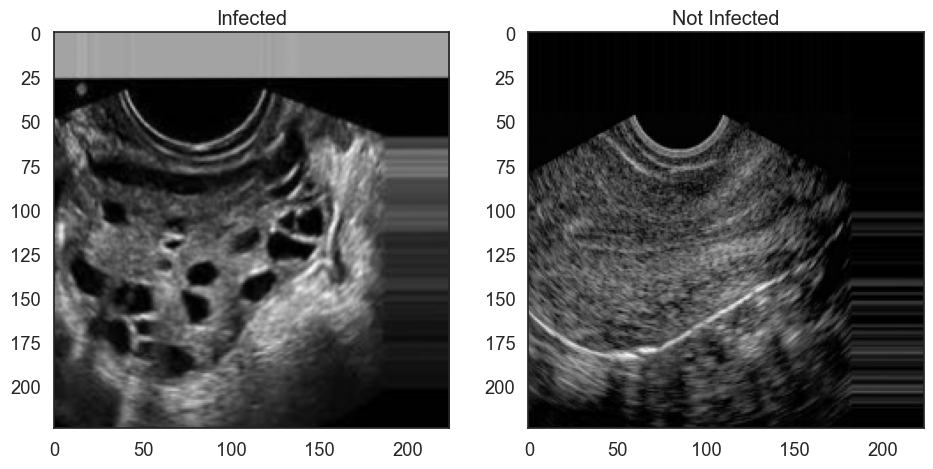

In [425]:
P.display_examples()

## Classic CV Model

In [553]:
class Annotate:
    def __init__(self):
        pass

    @staticmethod
    def intensity_transformation(img, gamma=1.0):
        """Enhances details in shadowed areas (if gamma > 1)."""
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 
                          for i in np.arange(0, 256)]).astype("uint8")
        return cv2.LUT(img, table)
    
    @staticmethod
    def apply_clahe(img, clip=2.0, tile=(8, 8)):
        """Applies localised histogram equalisation."""
        clahe_obj = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
        return clahe_obj.apply(img)
    
    @staticmethod
    def denoise(img, d=7, sigma_color=50, sigma_space=50):
        """Reduces noise while preserving sharp edges."""
        return cv2.bilateralFilter(img, d, sigma_color, sigma_space)
    
    @staticmethod
    def spatial_filtering(img, ksize=5):
        """Removes granular noise."""
        ksize = ksize if ksize % 2 != 0 else ksize + 1
        return cv2.medianBlur(img, ksize)
    
    @staticmethod
    def segment_anechoic_regions(img, thresh_val=35):
        """Creates binary mask."""
        _, binary = cv2.threshold(img, thresh_val, 255, cv2.THRESH_BINARY_INV)
        return binary
    
    @staticmethod
    def refine_mask(mask, ksize=5):
        """Remove small specles."""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        refined = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel)
        return refined
    
    def annotate_mask(self, original_gray, mask, min_circularity=0.2, min_solidity=0.7, area_ratio=0.0005):
        """Finds follicules."""
        annotated = cv2.cvtColor(original_gray, cv2.COLOR_GRAY2BGR)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        h, w = original_gray.shape
        min_area = area_ratio * h * w
        count = 0
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            if area < min_area or perimeter == 0: continue
            
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            solidity = float(area) / hull_area if hull_area > 0 else 0
            circularity = (4 * np.pi * area) / (perimeter ** 2)
            
            if solidity > min_solidity and circularity > min_circularity:
                count += 1
                
                s_score = (solidity - min_solidity) / (1.0 - min_solidity)
                c_score = (circularity - min_circularity) / (1.0 - min_circularity)
                confidence = (s_score + c_score) / 2
                confidence = np.clip(confidence, 0, 1)

                # As confidence goes up, Green increases and Red decreases
                color = (0, int(255 * confidence), int(255 * (1 - confidence)))
                
                if len(cnt) >= 5:
                    ellipse = cv2.fitEllipse(cnt)
                    cv2.ellipse(annotated, ellipse, color, 2)
                    
                    cv2.putText(annotated, f"{confidence:.2f}", (int(ellipse[0][0]), int(ellipse[0][1])), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    
        return annotated, count

    def apply_pipeline(self, img, 
                       gamma=1.4, clahe_clip=2.8, clahe_tile=(8,8),
                       d=4, sigma_color=51, sigma_space=71,
                       median_ksize=9, thresh_val=45, morph_ksize=9,
                       min_circularity=0.17, min_solidity=0.76,
                       area_ratio=0.0005, plot=False):
        
        steps = []
        steps.append(("Original", img))

        res_gamma = self.intensity_transformation(img, gamma=gamma)
        steps.append(("Gamma Correction", res_gamma))
        
        res_clahe = self.apply_clahe(res_gamma, clip=clahe_clip, tile=clahe_tile)
        steps.append(("CLAHE", res_clahe))
        
        res_denoise = self.denoise(res_clahe, d=d, sigma_color=sigma_color, sigma_space=sigma_space)
        res_smooth = self.spatial_filtering(res_denoise, ksize=median_ksize)
        steps.append(("Denoise & Blur", res_smooth))
        
        mask_raw = self.segment_anechoic_regions(res_smooth, thresh_val=thresh_val)
        steps.append(("Binary Mask", mask_raw))
        
        mask_refined = self.refine_mask(mask_raw, ksize=morph_ksize)
        steps.append(("Refined Mask", mask_refined))
        
        final_img, count = self.annotate_mask(img, mask_refined, 
                                              min_circularity=min_circularity, 
                                              min_solidity=min_solidity,
                                              area_ratio=area_ratio)
        steps.append((f"Final (Found: {count})", final_img))

        if plot:
            fig, axes = plt.subplots(1, len(steps), figsize=(20, 5))
            for i, (title, step_img) in enumerate(steps):
                axes[i].imshow(step_img, cmap='gray')
                axes[i].set_title(title)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()

        return final_img, count


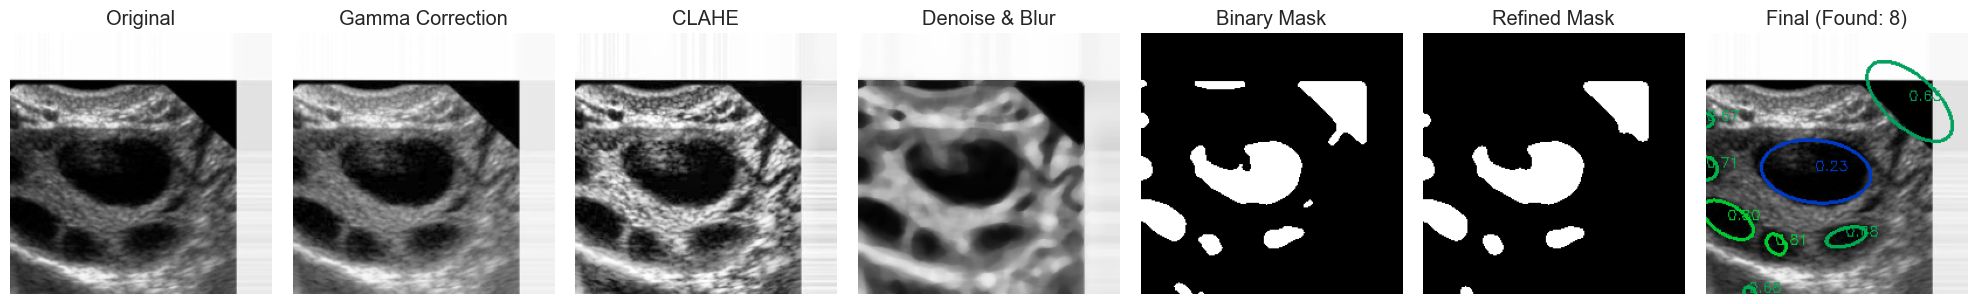

Detected 8 potential cysts.
True label: 0


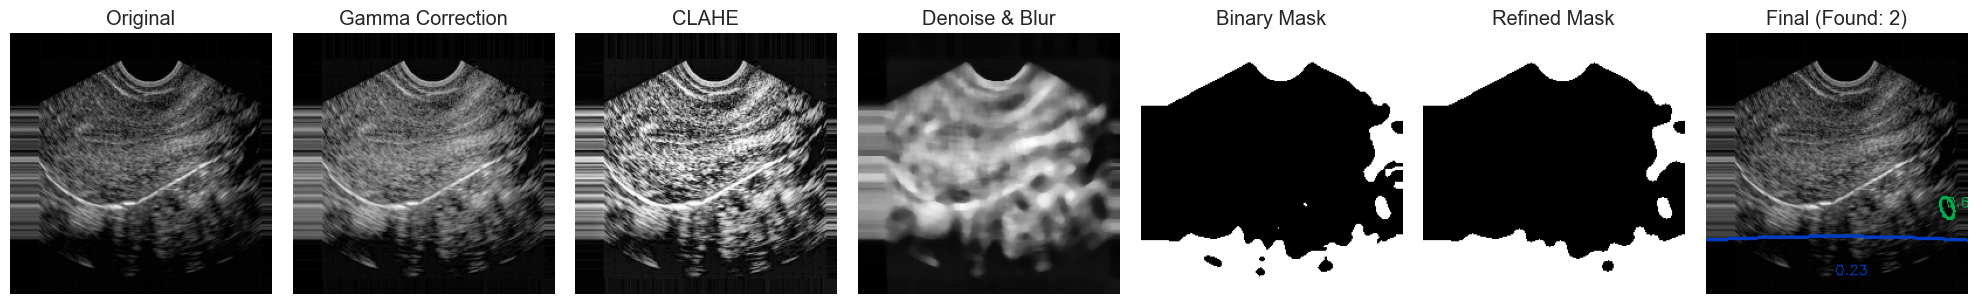

Detected 2 potential cysts.
True label: 1


In [554]:
engine = Annotate()

img, label = P.train_cv[0] 
result_img, cyst_count = engine.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")

img, label = P.train_cv[-1] 
result_img, cyst_count = engine.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")

In [ ]:
class ManualModel(Annotate):
    def __init__(self, train_dataset, val_dataset):
        super().__init__()
        self.dataset = train_dataset
        self.val_dataset = val_dataset
        self.engine = Annotate()
        self.best_params = None

    def infer_labels(self, threshold=7, indices=None, val=False, optimise=False, **kwargs):
        data = {"true_label": [], "pred_label": [], "count": [], "score": [], "is_correct": []}
        if val:
            dataset = self.val_dataset
        else:
            dataset = self.dataset
        target_indices = list(indices) if indices is not None else list(range(len(dataset)))

        params = kwargs.copy()
        if optimise and self.best_params is not None:
            params.update(self.best_params)
            threshold = params.pop("threshold", threshold)

        for i in tqdm(target_indices, desc="Inferring labels"):
            img, label = dataset[i]

            _, count = self.engine.apply_pipeline(img, **params)

            # Flip labels 1 = PCOS, 0 = Healthy
            true_label = 1 - int(label)

            score = count
            pred_label = 1 if score >= threshold else 0

            data["true_label"].append(true_label)
            data["pred_label"].append(pred_label)
            data["count"].append(count)
            data["score"].append(score)
            data["is_correct"].append(1 if true_label == pred_label else 0)

        return pd.DataFrame(data)

    def evaluate(self, df):
        if df.empty:
            return 0.0

        y_true = df["true_label"]
        y_pred = df["pred_label"]

        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        return {
            "accuracy": df["is_correct"].mean(),
            "recall": recall,
            "precision": precision,
            "f1": f1
        }

    def objective(self, trial):
        """Helper for optuna optimisation."""
        params = {
            'gamma': trial.suggest_float('gamma', 0.8, 1.5),
            'clahe_clip': trial.suggest_float('clahe_clip', 1.0, 3.0),
            'd': trial.suggest_int('d', 3, 9),
            'sigma_color': trial.suggest_int('sigma_color', 30, 80),
            'sigma_space': trial.suggest_int('sigma_space', 30, 80),
            'median_ksize': trial.suggest_int('median_ksize', 3, 9, step=2),
            'thresh_val': trial.suggest_int('thresh_val', 20, 50),
            'morph_ksize': trial.suggest_int('morph_ksize', 3, 9, step=2),
            'min_circularity': trial.suggest_float('min_circularity', 0.1, 0.4),
            'min_solidity': trial.suggest_float('min_solidity', 0.6, 0.95),
            'area_ratio': trial.suggest_float('area_ratio', 0.0001, 0.001),
            'threshold': trial.suggest_int('threshold', 6, 8)
        }

        total_len = len(self.dataset)
        for step, size in enumerate([int(total_len * 0.1), total_len]):
            df = self.infer_labels(indices=range(size), **params)
            acc = self.evaluate(df)["accuracy"]

            trial.report(acc, step=step)
            if trial.should_prune():
                raise optuna.TrialPruned()
            
            print(f"Trial {trial.number}: Accuracy={acc:.3f}")


        return acc

    def run_pcos_optimisation(self, n_trials=50):
        """Runs Optuna optimisation and stores the best parameters."""
        study = optuna.create_study(direction="maximize", pruner=optuna.pruners.SuccessiveHalvingPruner())
        study.optimize(self.objective, n_trials=n_trials)
        self.best_params = study.best_params
        return self.best_params

    def find_best_threshold(self, df, strategy="recall", target_recall=1.0):
        y_true = df["true_label"]
        y_score = df["score"]

        fpr, tpr, thresholds = roc_curve(y_true, y_score)

        if strategy == "youden":
            idx = (tpr - fpr).argmax()
        elif strategy == "recall":
            idx = tpr.argmax()
        elif strategy == "target_recall":
            valid = (tpr >= target_recall)
            idx = valid.nonzero()[0][fpr[valid].argmin()]
        else:
            raise ValueError("Unknown strategy")

        return {
            "threshold": thresholds[idx],
            "tpr": tpr[idx],
            "fpr": fpr[idx]
        }

    def plot_roc_curve(self, df):
        if df.empty:
            return

        y_true = df["true_label"]
        y_score = df["score"]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title("ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_confusion_matrix(self, df):
        if df.empty:
            return None, None

        cm = confusion_matrix(df["true_label"], df["pred_label"], labels=[1, 0])
        disp = ConfusionMatrixDisplay(cm, display_labels=["PCOS", "Healthy"])

        fig, ax = plt.subplots(figsize=(6,6))
        disp.plot(cmap=plt.cm.Greens, ax=ax)
        ax.set_title("Confusion Matrix")

        return fig, disp

In [586]:
MM = ManualModel(P.train_cv)
df = MM.infer_labels()
MM.evaluate(df)

Inferring labels: 100%|██████████| 1538/1538 [00:03<00:00, 509.44it/s]


{'accuracy': 0.9791937581274383,
 'recall': 0.9792,
 'precision': 0.9698890649762282,
 'f1': 0.9745222929936306}

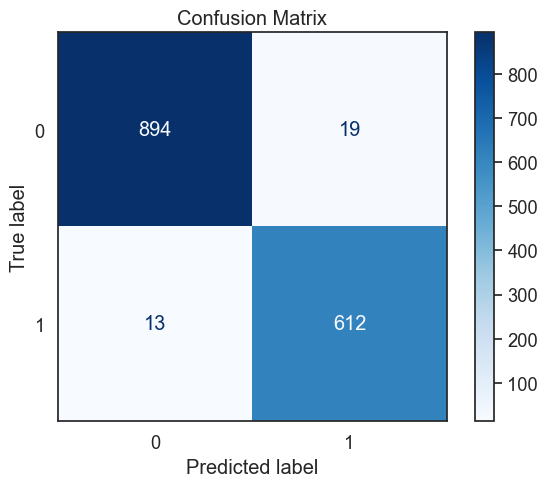

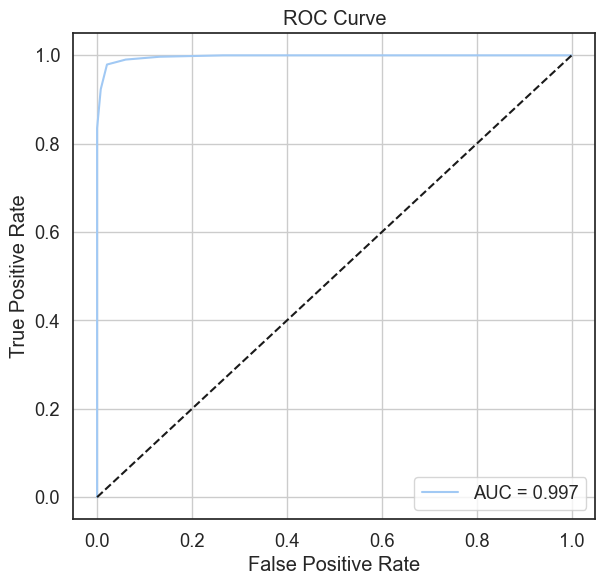

In [587]:
MM.plot_confusion_matrix(df)
MM.plot_roc_curve(df)

In [588]:
MM.run_pcos_optimisation()

[I 2026-03-19 22:50:46,085] A new study created in memory with name: no-name-168e430a-d0e3-4748-b79a-612ba49d8d24
Inferring labels: 100%|██████████| 153/153 [00:00<00:00, 554.83it/s]


Trial 0: Accuracy=0.935


Inferring labels: 100%|██████████| 1538/1538 [00:02<00:00, 592.83it/s]
[I 2026-03-19 22:50:48,966] Trial 0 finished with value: 0.8927178153446034 and parameters: {'gamma': 0.9178603519875541, 'clahe_clip': 2.6404954048798146, 'd': 5, 'sigma_color': 59, 'sigma_space': 66, 'median_ksize': 9, 'thresh_val': 35, 'morph_ksize': 3, 'min_circularity': 0.10858327943980257, 'min_solidity': 0.7572203664396442, 'area_ratio': 0.0008832244796025393, 'threshold': 6}. Best is trial 0 with value: 0.8927178153446034.


Trial 0: Accuracy=0.893


Inferring labels: 100%|██████████| 153/153 [00:00<00:00, 556.65it/s]


...

Trial 498: Accuracy=0.980


Inferring labels: 100%|██████████| 153/153 [00:00<00:00, 558.74it/s]


Trial 499: Accuracy=0.980


Inferring labels: 100%|██████████| 1538/1538 [00:02<00:00, 526.83it/s]
[I 2026-03-19 23:15:30,491] Trial 499 pruned. 


{'gamma': 0.8493436588008445,
 'clahe_clip': 1.26549478907687,
 'd': 6,
 'sigma_color': 60,
 'sigma_space': 53,
 'median_ksize': 9,
 'thresh_val': 28,
 'morph_ksize': 9,
 'min_circularity': 0.11059126100413152,
 'min_solidity': 0.7951776908141901,
 'area_ratio': 0.0009410160033455851,
 'threshold': 6}

In [591]:
df_optim = MM.infer_labels(optimise=True)
MM.evaluate(df_optim)

Inferring labels: 100%|██████████| 1538/1538 [00:03<00:00, 399.11it/s]


{'accuracy': 0.9830949284785435,
 'recall': 0.9744,
 'precision': 0.9838449111470113,
 'f1': 0.9790996784565916}

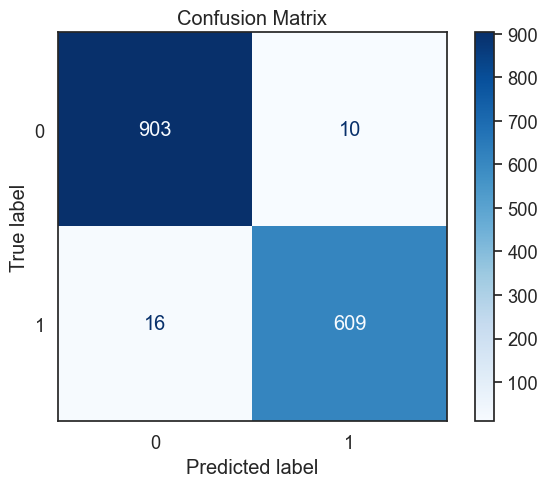

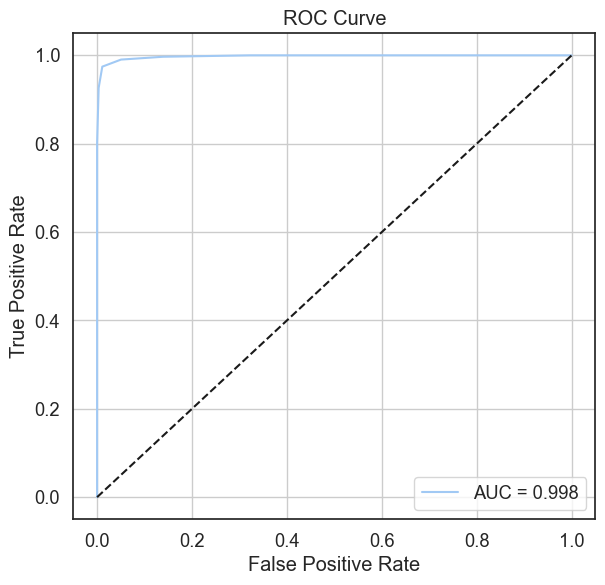

In [592]:
MM.plot_confusion_matrix(df_optim)
MM.plot_roc_curve(df_optim)

In [351]:
MMval = ManualModel(P.val_cv)
dfval = MMval.infer_labels()
MMval.evaluate(dfval)

0.9895833333333334

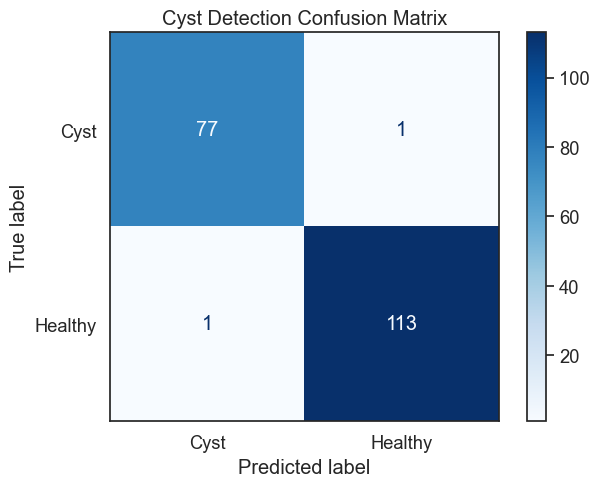

In [432]:
cm1 = confusion_matrix(dfval["true_label"], dfval["pred_label"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Cyst', 'Healthy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Cyst Detection Confusion Matrix")
plt.show()

## CNN Model

In [501]:
class CNNModel(nn.Module):
    def __init__(self, input_shape: Tuple[int, int, int] = (1, 224, 224), num_classes: int = 2, filter_out1=8, filter_out2=16,
                 pool_kernel1: int = 2, pool_kernel2: int = 2) -> None:
        super().__init__()

        self.filter_out1 = filter_out1
        self.filter_out2 = filter_out2
        self.pool_kernel1 = pool_kernel1
        self.pool_kernel2 = pool_kernel2

        self.c1 = nn.Conv2d(1, self.filter_out1, kernel_size=3, padding=1)
        self.c2 = nn.Conv2d(self.filter_out1, self.filter_out2, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=pool_kernel1, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=pool_kernel2, stride=2)

        with torch.no_grad():
            x = torch.zeros(1, *input_shape)
            x = self.pool1(F.relu(self.c1(x)))
            x = self.pool2(F.relu(self.c2(x)))
            n_features = x.view(1, -1).size(1)

        self.dense = nn.Linear(n_features, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.c1(x))
        x = self.pool1(x)
        x = F.relu(self.c2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = self.dense(x)
        return x

    def train_step(
        self,
        batch: Tuple[torch.Tensor, torch.Tensor],
        device: torch.device,
        criterion: nn.Module,
        optimizer: Optimizer
    ) -> float:
        self.train()
        data, targets = batch
        data, targets = data.to(device), targets.to(device)

        optimizer.zero_grad()
        scores = self(data)
        loss = criterion(scores, targets)
        loss.backward()
        optimizer.step()
        return loss.item()

    def validation_step(
        self,
        batch: Tuple[torch.Tensor, torch.Tensor],
        device: torch.device,
        criterion: nn.Module
    ) -> Tuple[float, float]:
        self.eval()
        data, targets = batch
        data, targets = data.to(device), targets.to(device)

        with torch.no_grad():
            scores = self(data)
            loss = criterion(scores, targets)
            _, preds = scores.max(1)
            accuracy = (preds == targets).sum().item() / data.size(0)

        return loss.item(), accuracy
    

In [ ]:
class Evaluator:
    def __init__(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        device: Optional[torch.device] = None,
        lr: float = 1e-3,
        num_epochs: int = 10
    ):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.num_epochs = num_epochs

        self.train_losses: List[float] = []
        self.val_losses: List[float] = []
        self.train_accs: List[float] = []
        self.val_accs: List[float] = []

    def reset_weights(self) -> None:
        """Reset model weights to start training from scratch."""
        def weight_reset(m: nn.Module) -> None:
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                m.reset_parameters()
        self.model.apply(weight_reset)

        # Reset history
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

    def train_one_epoch(self) -> None:
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch in self.train_loader:
            data, targets = batch
            targets = 1 - targets
            data, targets = data.to(self.device), targets.to(self.device)

            self.optimizer.zero_grad()
            scores = self.model(data)
            loss = self.criterion(scores, targets)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * data.size(0)
            preds = scores.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        self.train_losses.append(epoch_loss)
        self.train_accs.append(epoch_acc)

    def validate_one_epoch(self) -> Tuple[List[int], List[float]]:
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_targets: List[int] = []
        all_probs: List[float] = []

        with torch.no_grad():
            for batch in self.val_loader:
                data, targets = batch
                targets = 1 - targets
                data, targets = data.to(self.device), targets.to(self.device)

                scores = self.model(data)
                loss = self.criterion(scores, targets)

                running_loss += loss.item() * data.size(0)
                preds = scores.argmax(dim=1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)

                all_targets.extend(targets.cpu().numpy())
                probs = torch.softmax(scores, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        self.val_losses.append(epoch_loss)
        self.val_accs.append(epoch_acc)

        return all_targets, all_probs

    def train(self) -> None:
        """Trains the model and prints metrics per epoch."""
        self.reset_weights()

        for epoch in range(self.num_epochs):
            self.train_one_epoch()
            all_targets, all_probs = self.validate_one_epoch()

            fpr, tpr, _ = roc_curve(all_targets, all_probs)
            roc_auc = auc(fpr, tpr)

            print(f"Epoch {epoch+1}/{self.num_epochs} | "
                  f"Train Acc: {100*self.train_accs[-1]:.2f}% | "
                  f"Val Acc: {100*self.val_accs[-1]:.2f}% | "
                  f"AUC: {roc_auc:.3f}")
            
            if self.val_accs[-1] == 1:
                print(f"Validation accuracy reached 100% at epoch {epoch+1}. Stopping training.")
                break

    def tune_threshold(self, metric: str = "recall", num_steps: int = 100):

        self.model.eval()
        all_targets, all_probs = self.validate_one_epoch()

        thresholds = np.linspace(0, 1, num_steps)
        best_thresh = 0.5
        best_score = -1

        for t in thresholds:
            preds = [1 if p > t else 0 for p in all_probs]

            if metric == "f1":
                score = f1_score(all_targets, preds)
            elif metric == "precision":
                score = precision_score(all_targets, preds)
            elif metric == "recall":
                score = recall_score(all_targets, preds)
            elif metric == "accuracy":
                score = accuracy_score(all_targets, preds)
            else:
                raise ValueError(f"Unknown metric: {metric}")

            if score > best_score:
                best_score = score
                best_thresh = t

        print(f"Best threshold ({metric}): {best_thresh:.3f} | Score: {best_score:.4f}")
        return best_thresh, best_score

    def plot_learning_curve(self) -> None:
        plt.figure(figsize=(12,5))

        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, label="Train Loss", marker='o')
        plt.plot(self.val_losses, label="Val Loss", marker='o')
        plt.title("Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot([acc*100 for acc in self.train_accs], label="Train Acc", marker='o')
        plt.plot([acc*100 for acc in self.val_accs], label="Val Acc", marker='o')
        plt.title("Accuracy Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy (%)")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self) -> None:
        all_targets, all_probs = self.validate_one_epoch()
        fpr, tpr, _ = roc_curve(all_targets, all_probs)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1],[0,1],'k--')
        plt.title("ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

    def plot_confusion_matrix(self, threshold: float = 0.5) -> None:
        all_targets, all_probs = self.validate_one_epoch()
        preds = [1 if p > threshold else 0 for p in all_probs]

        cm = confusion_matrix(all_targets, preds)
        disp = ConfusionMatrixDisplay(cm)

        fig, ax = plt.subplots(figsize=(6,6))
        disp.plot(cmap=plt.cm.Blues, ax=ax)
        ax.set_title("Confusion Matrix")

        return fig, disp

    def plot_full_evaluation(self, threshold: float = 0.5) -> None:
        """
        Plot training/validation loss, accuracy, ROC curve, and confusion matrix.
        .
        """
        if hasattr(self, "_last_val_targets") and hasattr(self, "_last_val_probs"):
            all_targets = self._last_val_targets
            all_probs = self._last_val_probs
        else:
            all_targets, all_probs = self.validate_one_epoch()
            self._last_val_targets = all_targets
            self._last_val_probs = all_probs

        fpr, tpr, _ = roc_curve(all_targets, all_probs)
        roc_auc = auc(fpr, tpr)

        preds = [1 if p > threshold else 0 for p in all_probs]
        cm = confusion_matrix(all_targets, preds)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # loss
        axes[0, 0].plot(self.train_losses, label="Train Loss", marker='o')
        axes[0, 0].plot(self.val_losses, label="Val Loss", marker='o')
        axes[0, 0].set_title("Loss Curve")
        axes[0, 0].set_xlabel("Epoch")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # acc
        axes[0, 1].plot([acc*100 for acc in self.train_accs], label="Train Acc", marker='o')
        axes[0, 1].plot([acc*100 for acc in self.val_accs], label="Val Acc", marker='o')
        axes[0, 1].set_title("Accuracy Curve")
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].set_ylabel("Accuracy (%)")
        axes[0, 1].legend()
        axes[0, 1].grid(True)

        # roc
        axes[1, 0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        axes[1, 0].plot([0, 1], [0, 1], 'k--')
        axes[1, 0].set_title("ROC Curve")
        axes[1, 0].set_xlabel("False Positive Rate")
        axes[1, 0].set_ylabel("True Positive Rate")
        axes[1, 0].legend()
        axes[1, 0].grid(True)

        # cm
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(ax=axes[1, 1], cmap=plt.cm.Blues, colorbar=False)
        axes[1, 1].set_title(f"Confusion Matrix (t={threshold:.2f})")

        plt.tight_layout()
        plt.show()

    def run(self) -> None:
        """Run full training and evaluation pipeline."""
        print("Starting training...")
        self.train()
        print("Training complete. Plotting results...")
        self.plot_full_evaluation()
        print("Tuning...")
        best_t, _ = self.tune_threshold(metric="f1")
        self.plot_full_evaluation(threshold=best_t)
        print("Evaluation complete.")

Starting training...
Epoch 1/10 | Train Acc: 79.13% | Val Acc: 85.94% | AUC: 0.955
Epoch 2/10 | Train Acc: 91.81% | Val Acc: 90.10% | AUC: 0.993
Epoch 3/10 | Train Acc: 96.23% | Val Acc: 98.44% | AUC: 0.998
Epoch 4/10 | Train Acc: 99.61% | Val Acc: 98.96% | AUC: 1.000
Epoch 5/10 | Train Acc: 99.93% | Val Acc: 98.44% | AUC: 1.000
Epoch 6/10 | Train Acc: 100.00% | Val Acc: 98.96% | AUC: 1.000
Epoch 7/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 8/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 9/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 10/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Training complete. Plotting results...


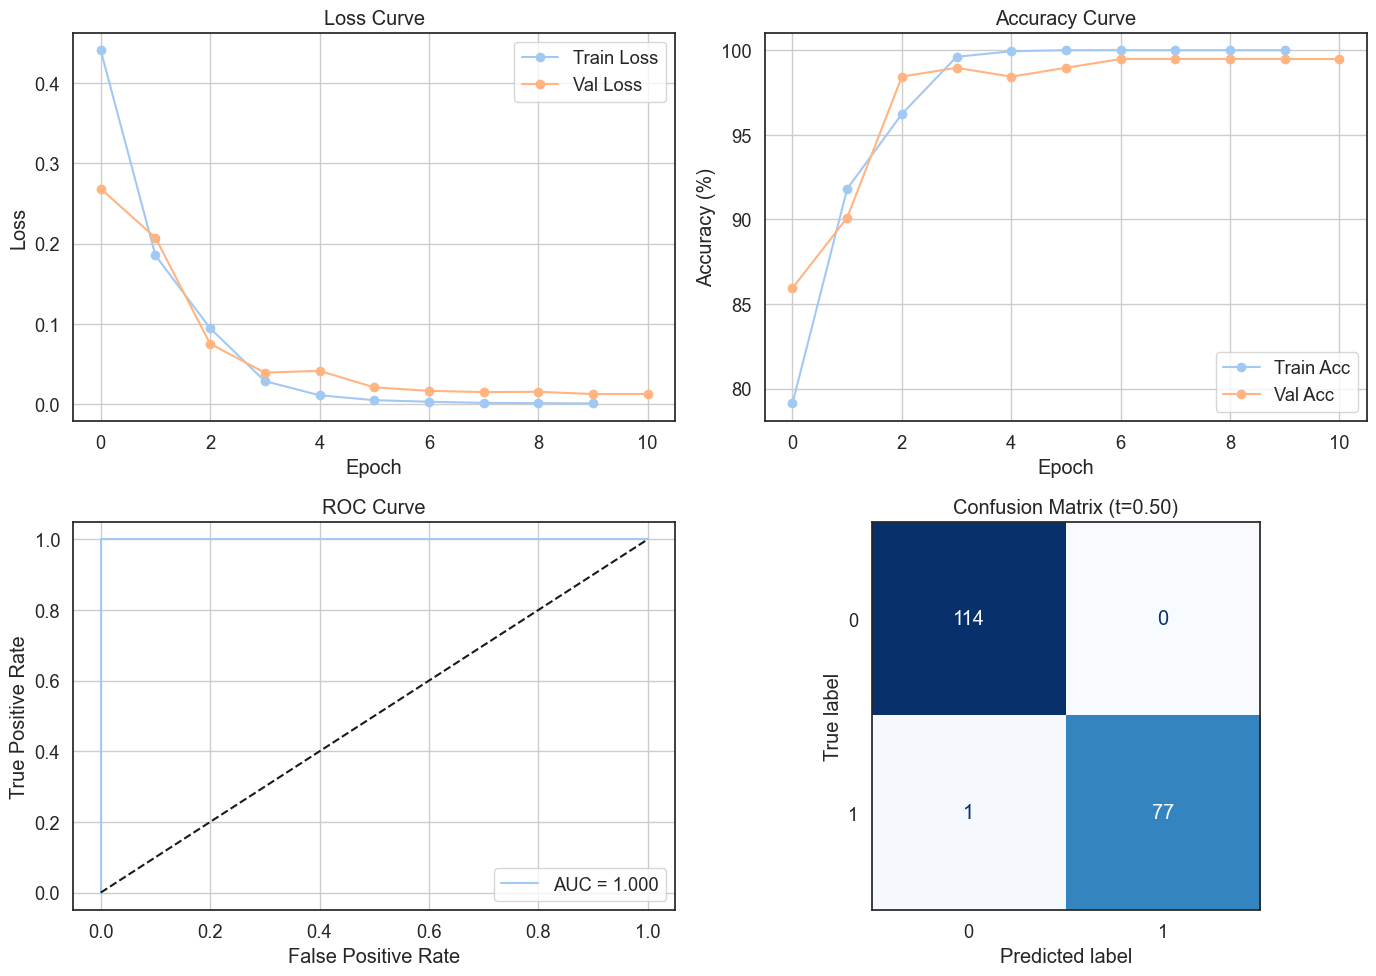

Tuning...
Best threshold (f1): 0.061 | Score: 1.0000


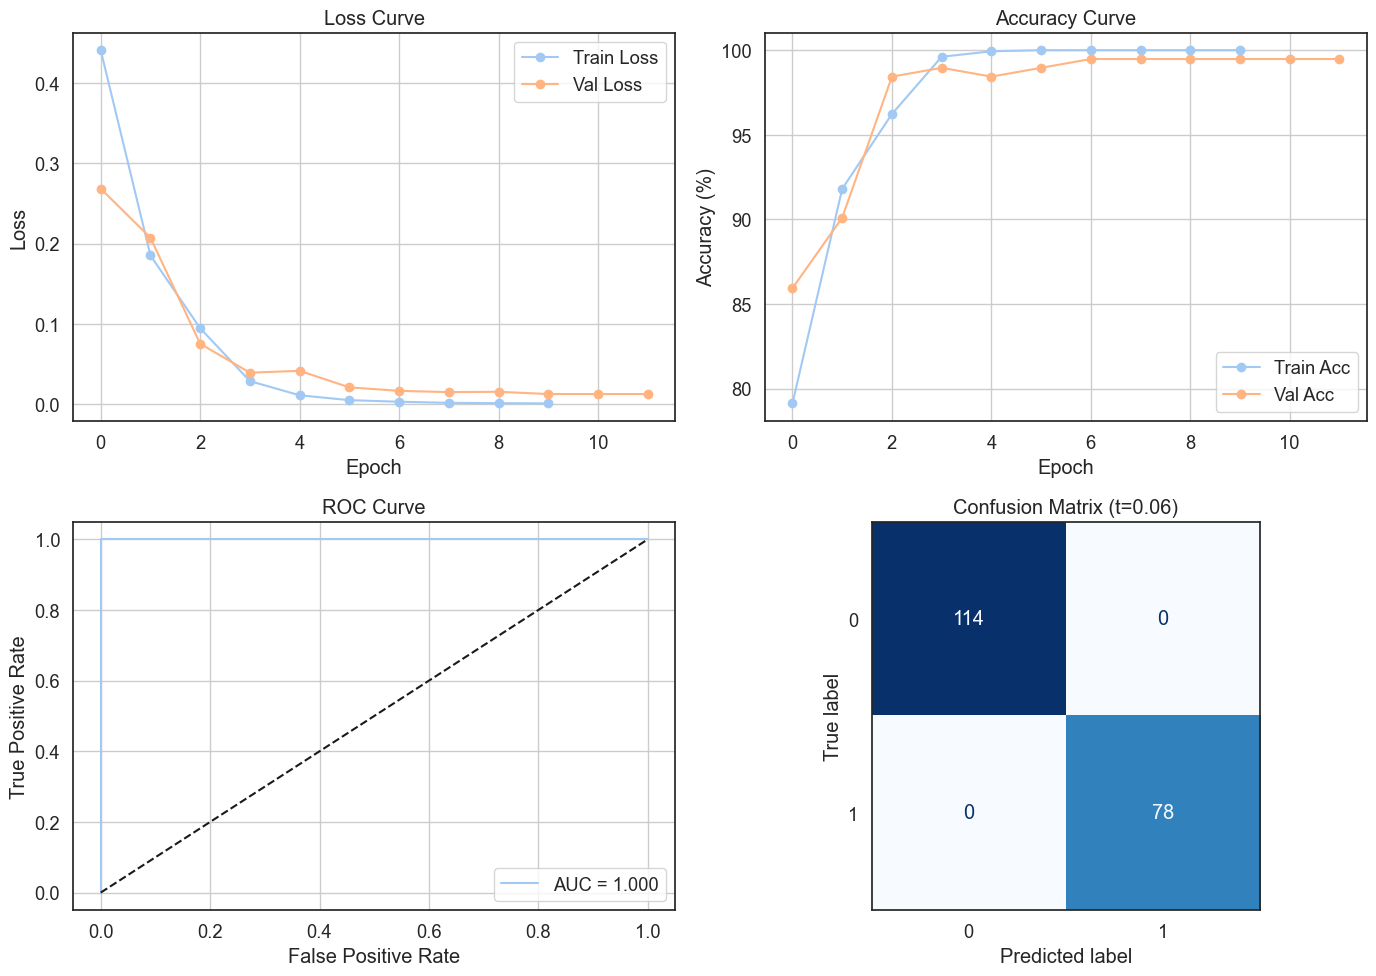

Evaluation complete.


In [507]:
train_loader = DataLoader(P.train_cnn, batch_size=64, shuffle=True)
val_loader = DataLoader(P.val_cnn, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNNModel(input_shape=(1,224,224))

evaluator = Evaluator(model, train_loader, val_loader, device=device, num_epochs=10)
evaluator.run()

Starting training...
Epoch 1/15 | Train Acc: 62.68% | Val Acc: 87.50% | AUC: 0.962
Epoch 2/15 | Train Acc: 90.05% | Val Acc: 92.19% | AUC: 0.980
Epoch 3/15 | Train Acc: 95.77% | Val Acc: 97.40% | AUC: 0.994
Epoch 4/15 | Train Acc: 98.24% | Val Acc: 96.35% | AUC: 0.997
Epoch 5/15 | Train Acc: 99.15% | Val Acc: 98.44% | AUC: 0.999
Epoch 6/15 | Train Acc: 99.67% | Val Acc: 98.96% | AUC: 0.999
Epoch 7/15 | Train Acc: 99.74% | Val Acc: 98.96% | AUC: 1.000
Epoch 8/15 | Train Acc: 99.87% | Val Acc: 99.48% | AUC: 1.000
Epoch 9/15 | Train Acc: 99.93% | Val Acc: 99.48% | AUC: 1.000
Epoch 10/15 | Train Acc: 100.00% | Val Acc: 98.96% | AUC: 1.000
Epoch 11/15 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 12/15 | Train Acc: 100.00% | Val Acc: 98.96% | AUC: 1.000
Epoch 13/15 | Train Acc: 100.00% | Val Acc: 98.96% | AUC: 1.000
Epoch 14/15 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 15/15 | Train Acc: 100.00% | Val Acc: 98.96% | AUC: 1.000
Training complete. Plotting results..

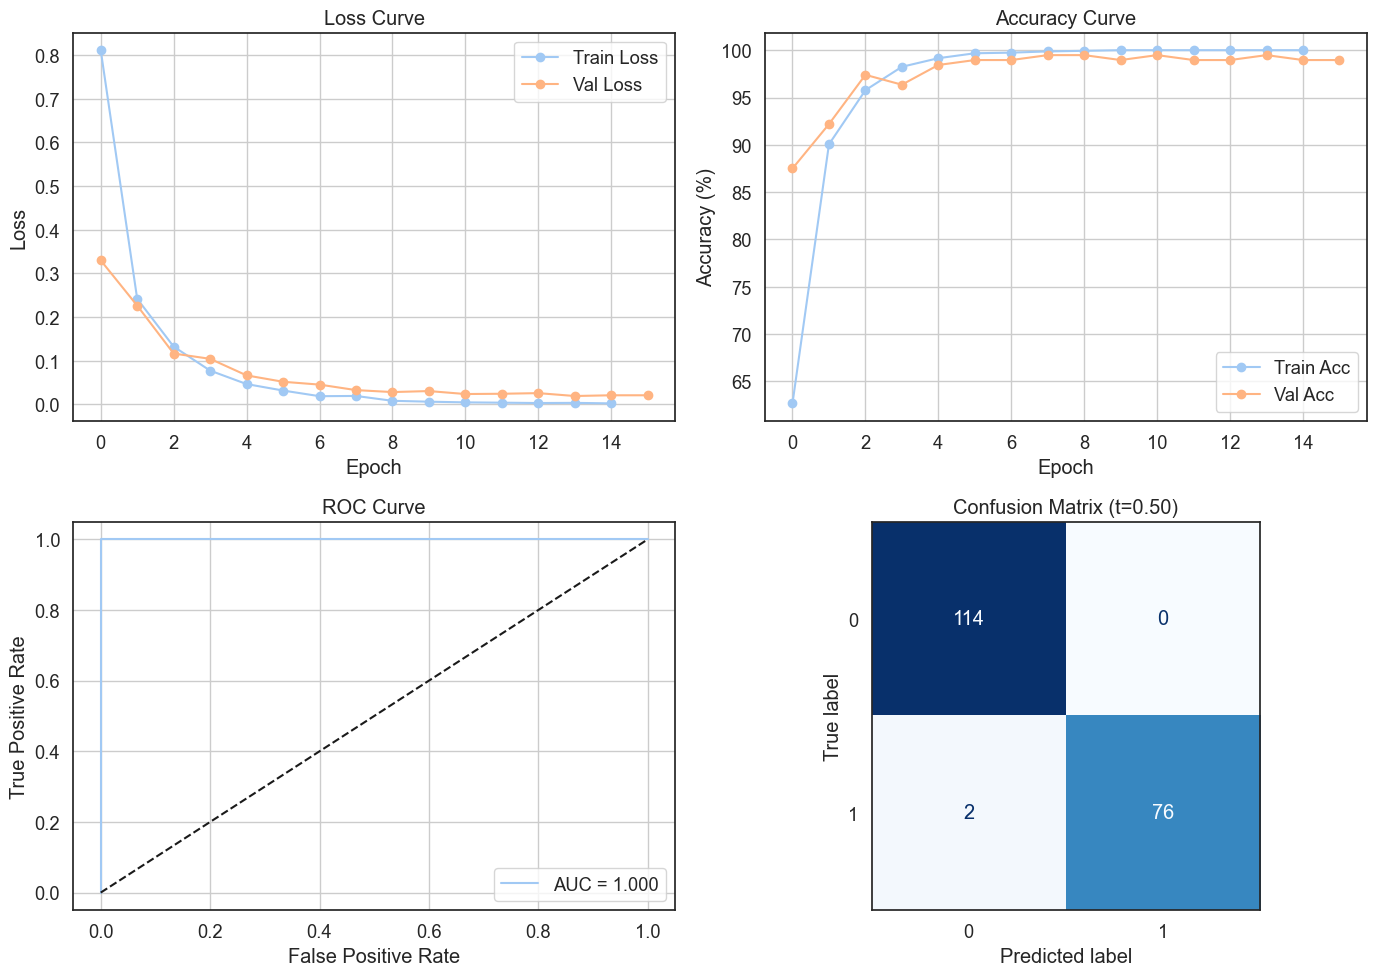

Tuning...
Best threshold (f1): 0.061 | Score: 1.0000


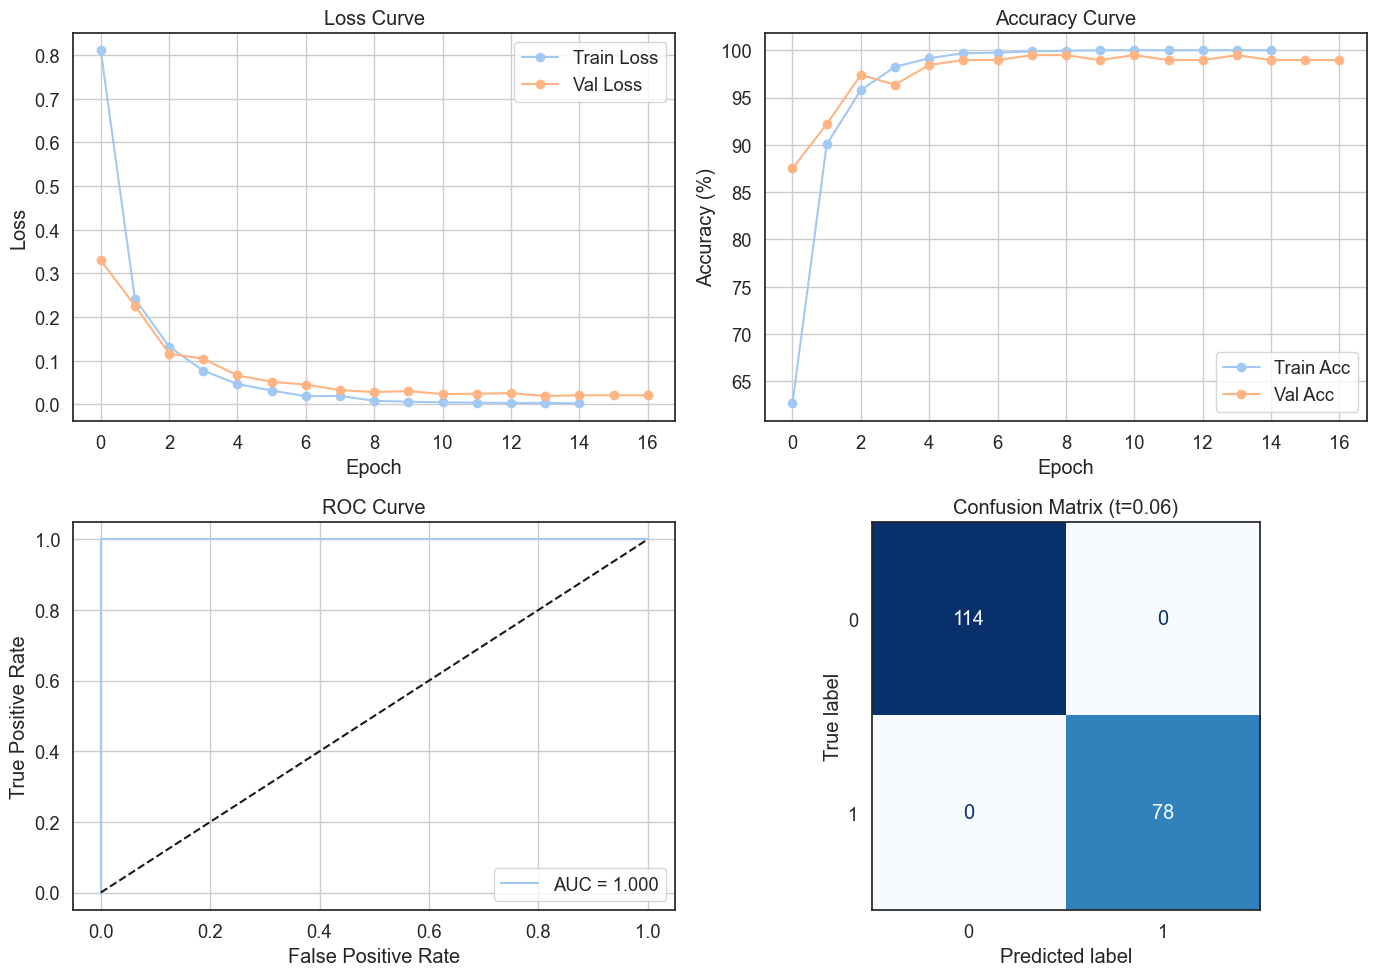

Evaluation complete.


In [509]:
model_reduced = CNNModel(input_shape=(1,224,224), filter_out1=4, filter_out2=8)

evaluator_reduced = Evaluator(model_reduced, train_loader, val_loader, device=device, num_epochs=15)
evaluator_reduced.run()

In [491]:
P28 = Prep(path, output_size=28)

Starting training...
Epoch 1/10 | Train Acc: 65.73% | Val Acc: 73.96% | AUC: 0.913
Epoch 2/10 | Train Acc: 83.22% | Val Acc: 86.98% | AUC: 0.929
Epoch 3/10 | Train Acc: 86.74% | Val Acc: 89.06% | AUC: 0.949
Epoch 4/10 | Train Acc: 89.60% | Val Acc: 87.50% | AUC: 0.966
Epoch 5/10 | Train Acc: 91.61% | Val Acc: 89.06% | AUC: 0.979
Epoch 6/10 | Train Acc: 93.63% | Val Acc: 94.79% | AUC: 0.989
Epoch 7/10 | Train Acc: 94.99% | Val Acc: 95.83% | AUC: 0.996
Epoch 8/10 | Train Acc: 96.49% | Val Acc: 96.88% | AUC: 0.998
Epoch 9/10 | Train Acc: 97.98% | Val Acc: 97.92% | AUC: 0.999
Epoch 10/10 | Train Acc: 97.59% | Val Acc: 97.40% | AUC: 0.999
Training complete. Plotting results...


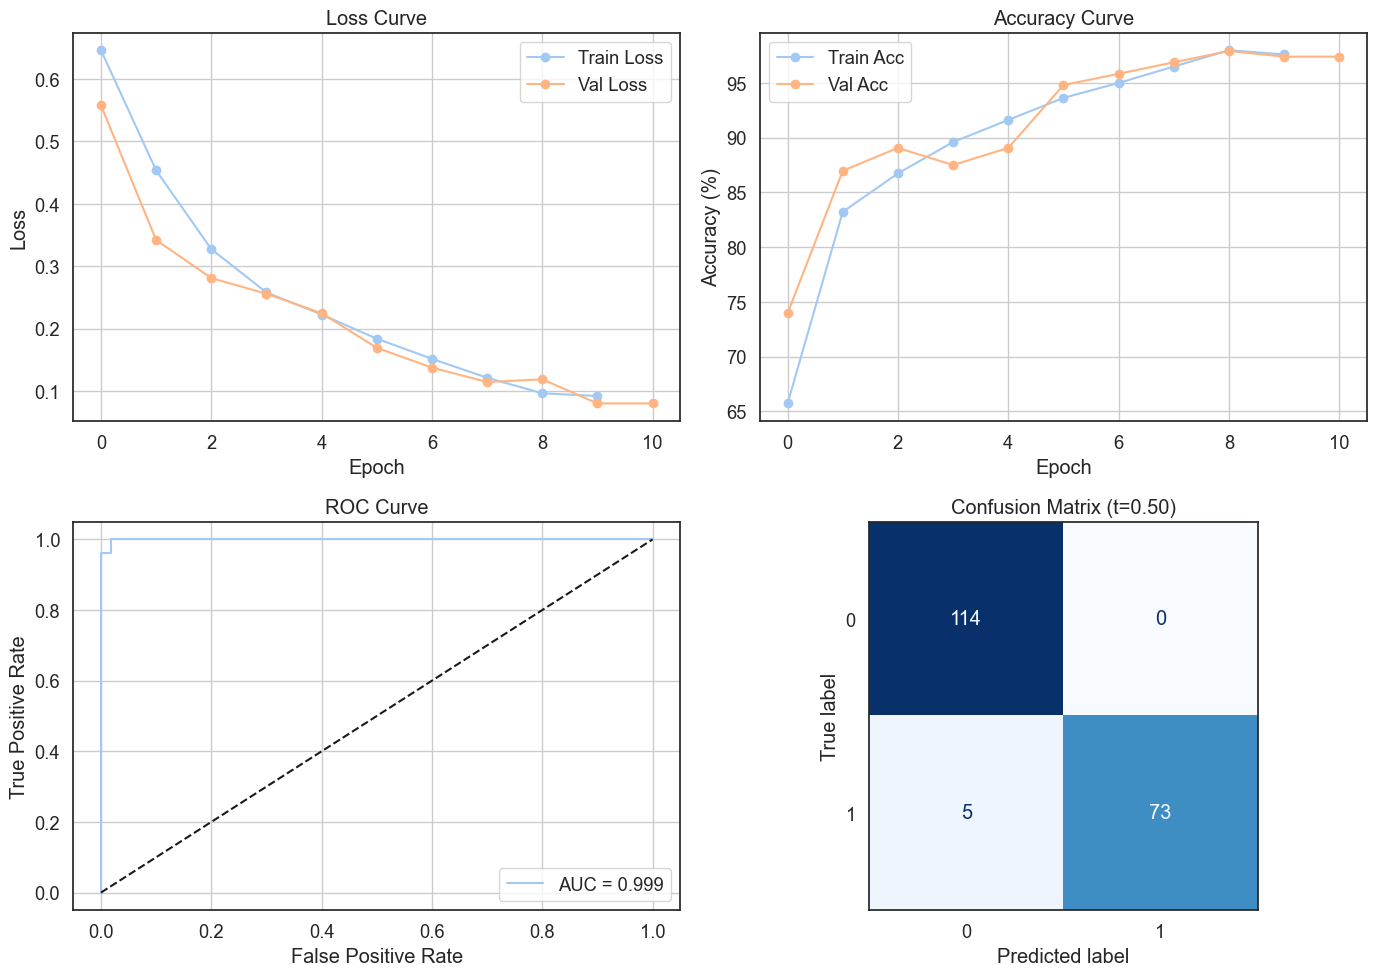

Tuning...
Best threshold (f1): 0.202 | Score: 0.9873


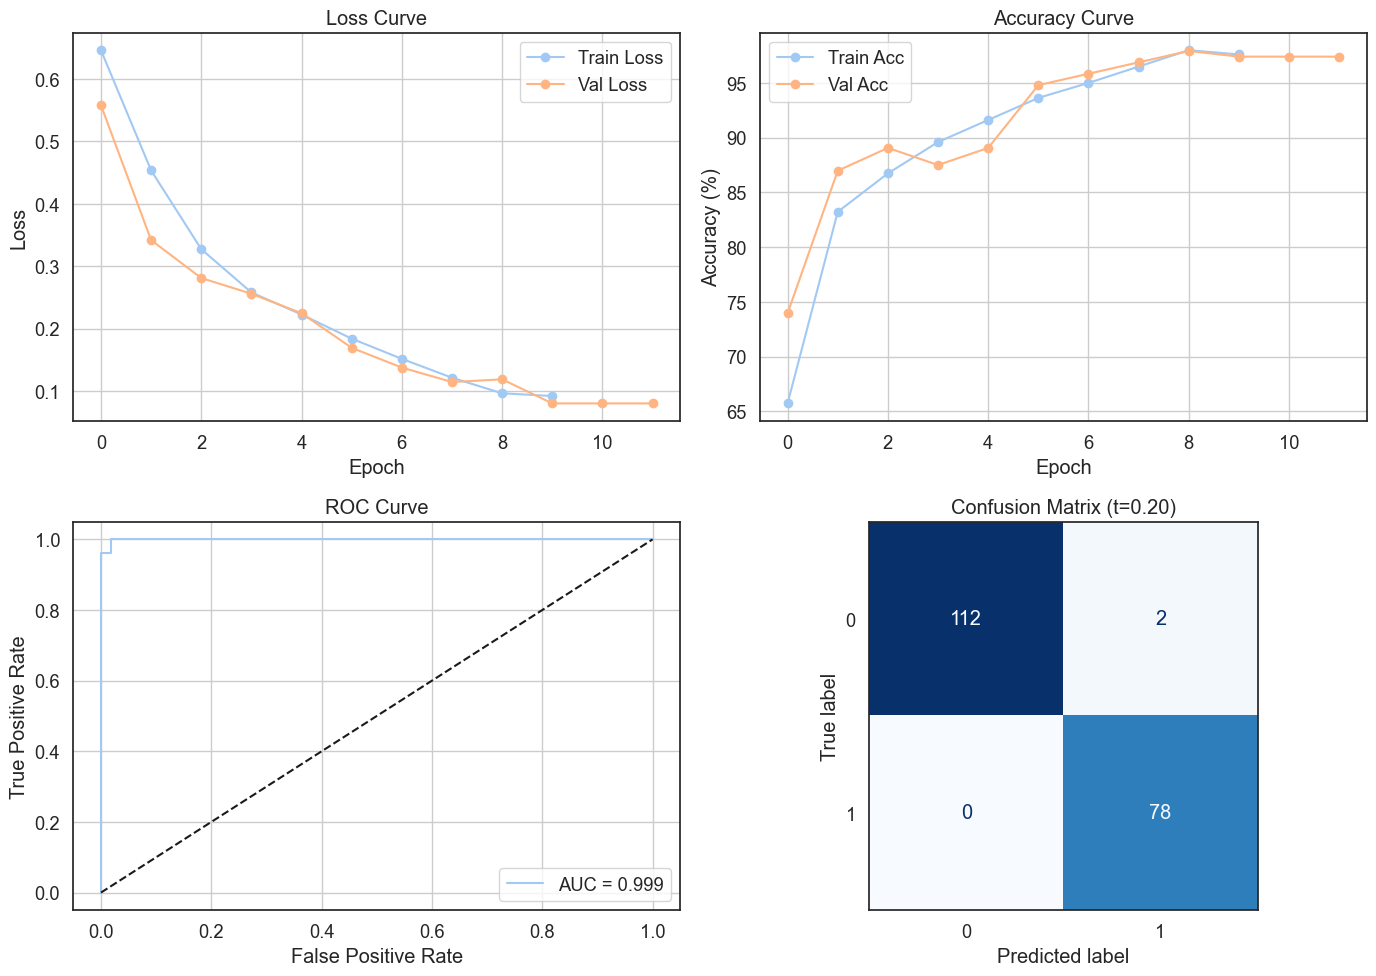

Evaluation complete.


In [492]:
train_loader28 = DataLoader(P28.train_cnn, batch_size=64, shuffle=True)
val_loader28 = DataLoader(P28.val_cnn, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model28 = CNNModel(input_shape=(1,28,28))

evaluator28 = Evaluator(model28, train_loader28, val_loader28, device=device, num_epochs=10)
evaluator28.run()

In [493]:
P16 = Prep(path, 16)

Starting training...
Epoch 1/15 | Train Acc: 63.07% | Val Acc: 67.19% | AUC: 0.951
Epoch 2/15 | Train Acc: 80.82% | Val Acc: 85.94% | AUC: 0.951
Epoch 3/15 | Train Acc: 85.89% | Val Acc: 88.02% | AUC: 0.948
Epoch 4/15 | Train Acc: 87.71% | Val Acc: 90.10% | AUC: 0.962
Epoch 5/15 | Train Acc: 90.96% | Val Acc: 91.67% | AUC: 0.974
Epoch 6/15 | Train Acc: 93.24% | Val Acc: 94.79% | AUC: 0.987
Epoch 7/15 | Train Acc: 95.32% | Val Acc: 96.35% | AUC: 0.996
Epoch 8/15 | Train Acc: 96.49% | Val Acc: 95.83% | AUC: 0.998
Epoch 9/15 | Train Acc: 96.88% | Val Acc: 98.96% | AUC: 0.999
Epoch 10/15 | Train Acc: 98.44% | Val Acc: 98.96% | AUC: 1.000
Epoch 11/15 | Train Acc: 98.76% | Val Acc: 98.96% | AUC: 1.000
Epoch 12/15 | Train Acc: 99.15% | Val Acc: 100.00% | AUC: 1.000
Validation accuracy reached 100% at epoch 12. Stopping training.
Training complete. Plotting results...


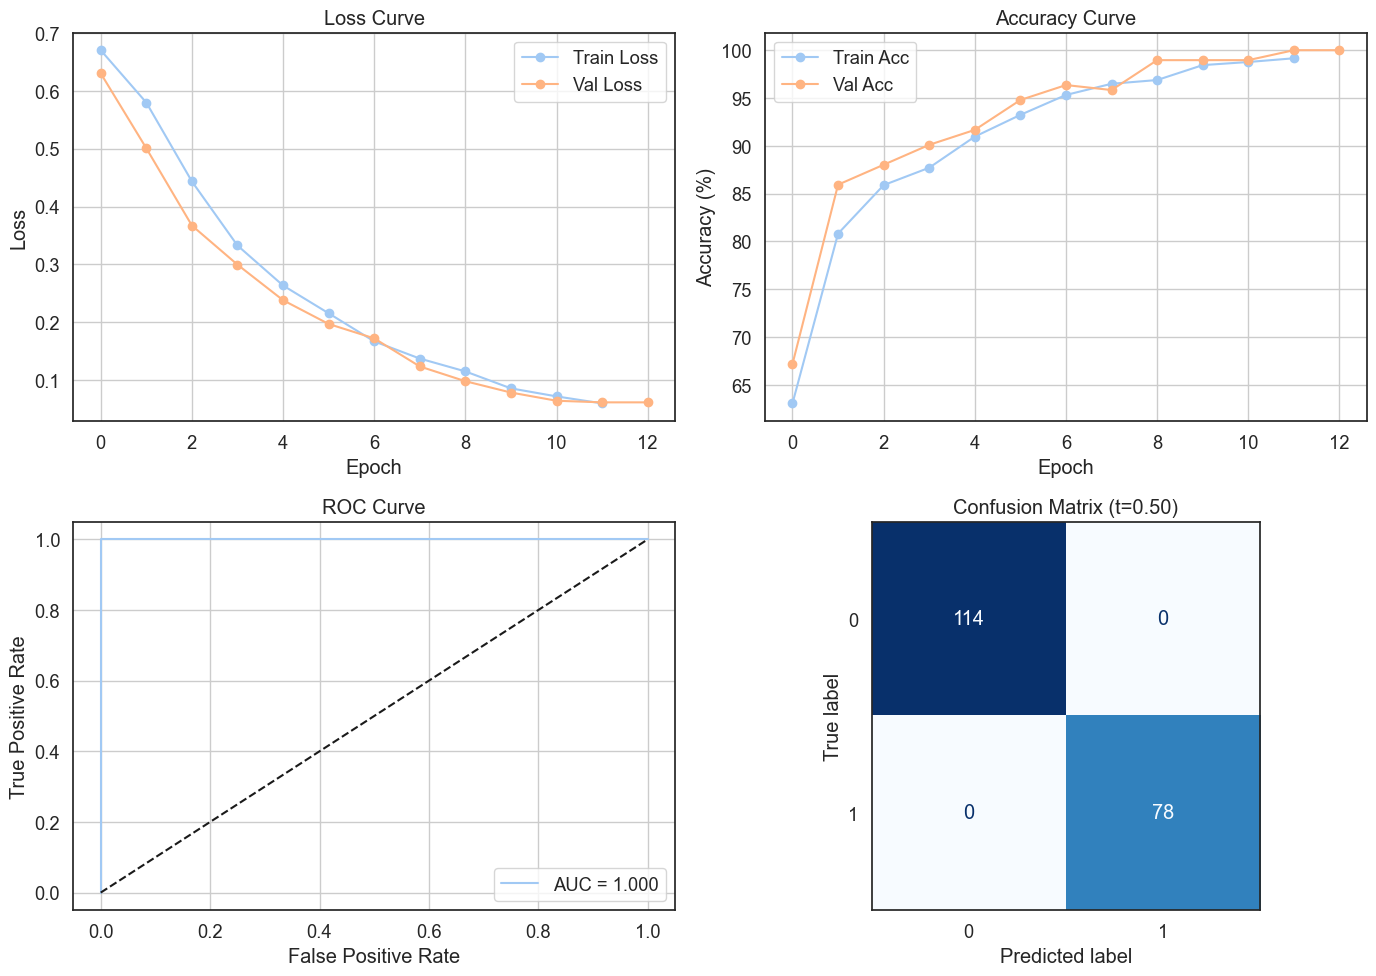

Tuning...
Best threshold (f1): 0.444 | Score: 1.0000


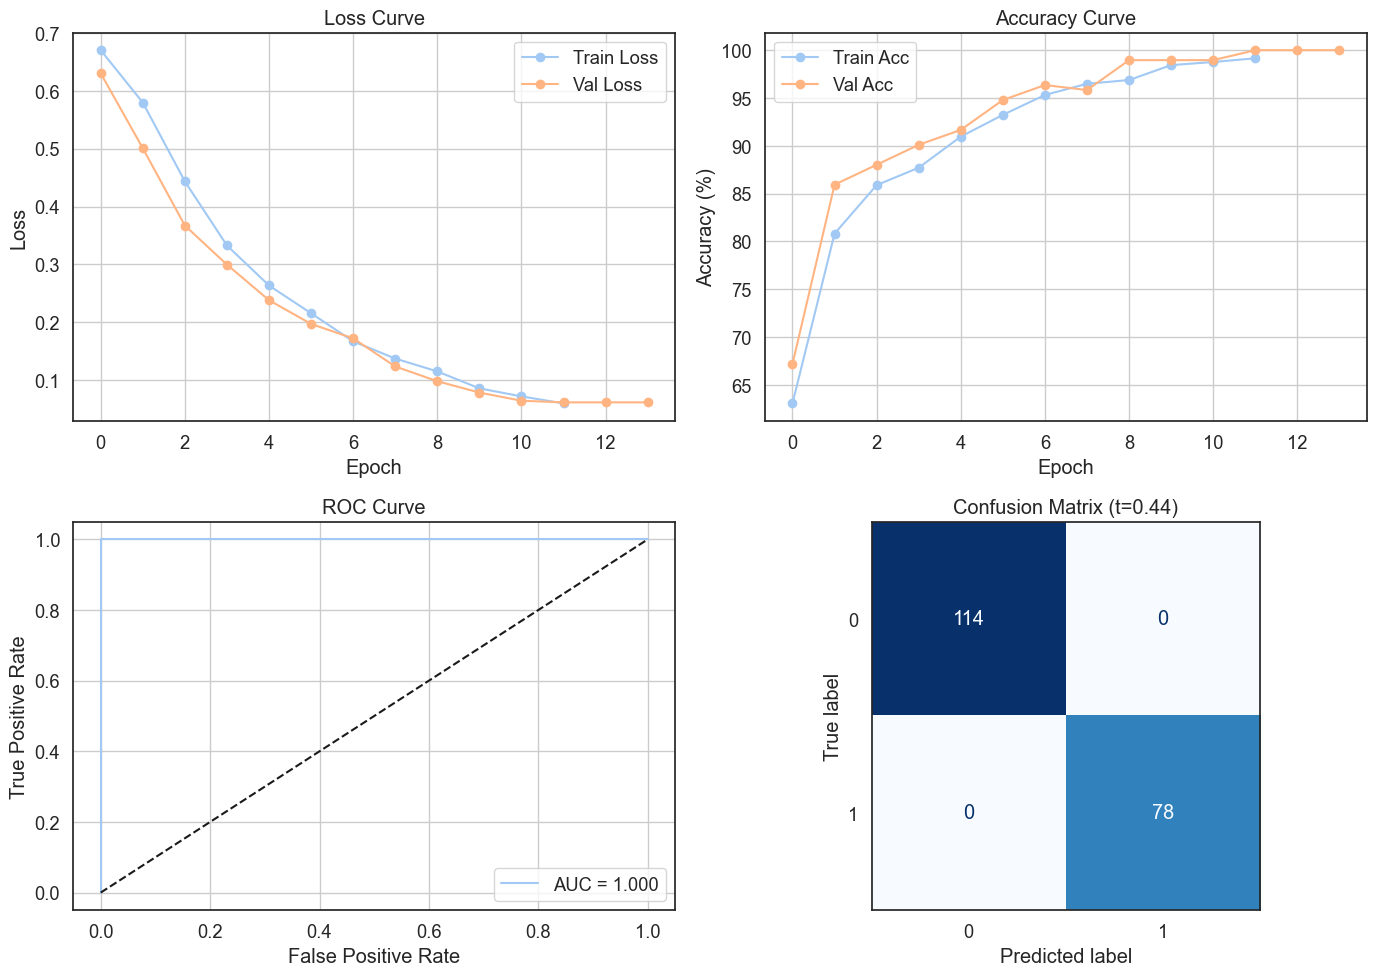

Evaluation complete.


In [494]:
train_loader16 = DataLoader(P16.train_cnn, batch_size=64, shuffle=True)
val_loader16 = DataLoader(P16.val_cnn, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model16 = CNNModel(input_shape=(1,16,16))

evaluator16 = Evaluator(model16, train_loader16, val_loader16, device=device, num_epochs=15)
evaluator16.run()

In [453]:
MM28 = ManualModel(P28.train_cv)
df28 = MM28.infer_labels()
MM28.evaluate(df28)

0.5936280884265279

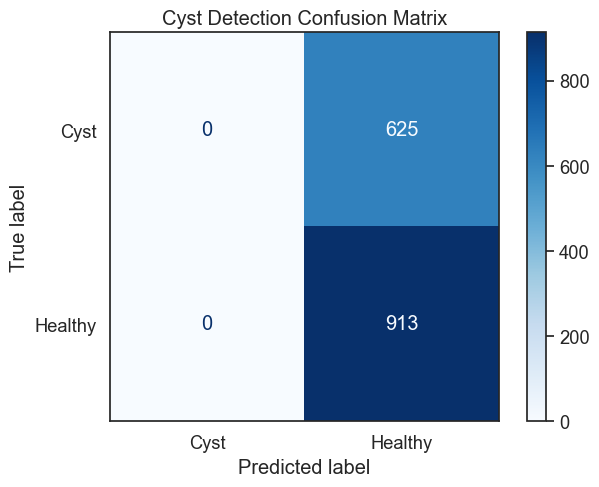

In [454]:
cm28 = confusion_matrix(df28["true_label"], df28["pred_label"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm28, display_labels=['Cyst', 'Healthy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Cyst Detection Confusion Matrix")
plt.show()

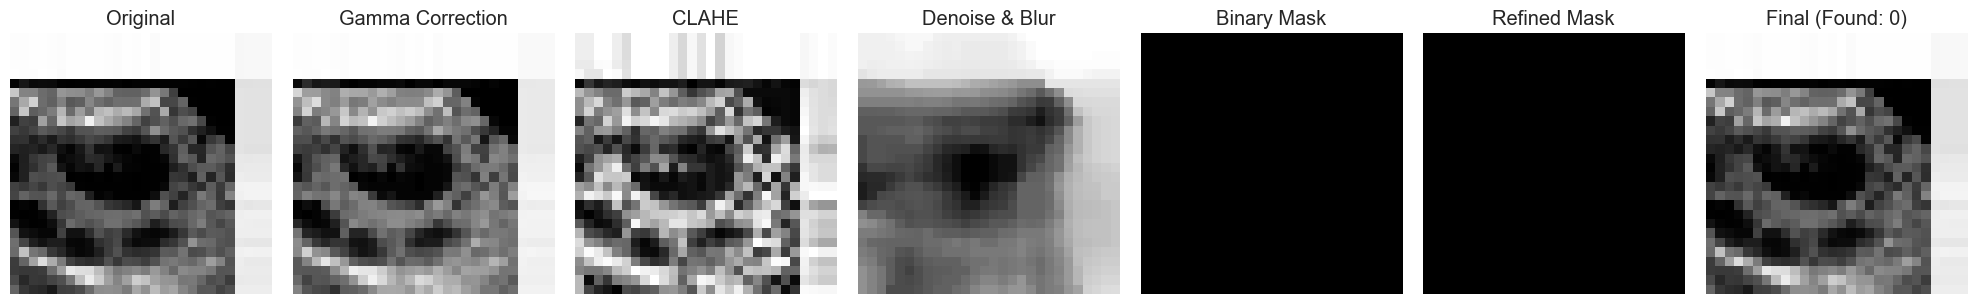

Detected 0 potential cysts.
True label: 0


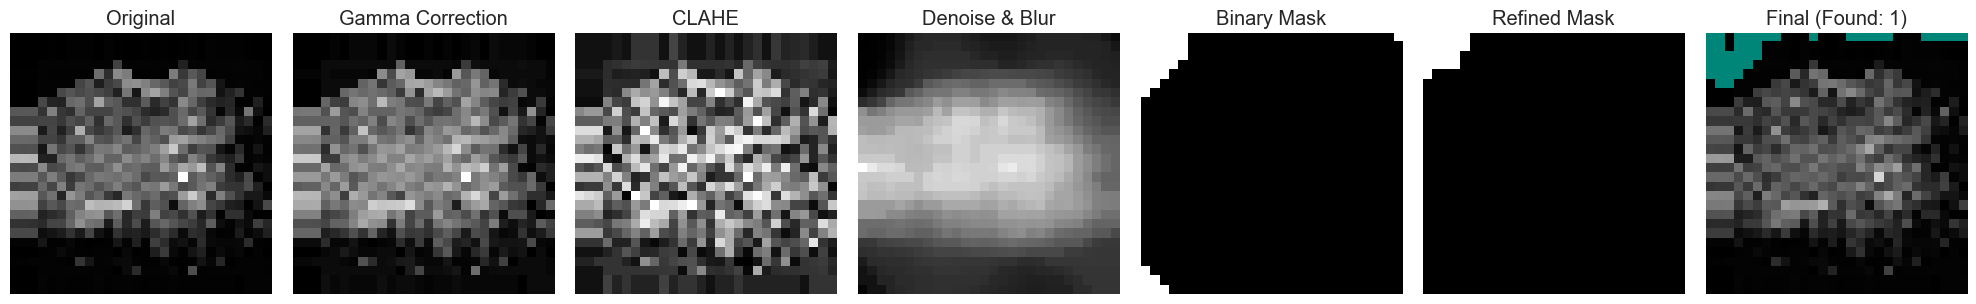

Detected 1 potential cysts.
True label: 1


In [452]:
engine28 = Annotate()

img, label = P28.train_cv[0] 
result_img, cyst_count = engine28.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")

img, label = P28.train_cv[-1] 
result_img, cyst_count = engine28.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")

In [590]:
def compare_models(dict_of_plots, cols=2, figsize_per_plot=(6,6)):
    n_plots = len(dict_of_plots)
    rows = (n_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per_plot[0]*cols, figsize_per_plot[1]*rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[n_plots:]:
        ax.axis('off')

    for i, (title, plot_fig) in enumerate(dict_of_plots.items()):
        for old_ax in plot_fig.axes:
            for artist in old_ax.get_children():
                try:
                    artist.remove()
                except Exception:
                    pass
            for artist in old_ax.get_children():
                axes[i]._add_text(artist) if hasattr(artist, "_add_text") else axes[i].add_artist(artist)
        
        axes[i].imshow(plot_fig.canvas.renderer.buffer_rgba())
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
CV28 = ManualModel(P28.train_cv, P28.val_cv)
CNN16r = CNNModel()

fig1, _ = MM.plot_confusion_matrix(df)
fig2, _ = evaluator.plot_confusion_matrix(0.061)
fig3, _ = 

plots_dict = {
    "224 CV Model": fig1,
    "224 CNN": fig2,
    "28 CV": fig3,
    "28 CNN": fig4,
    "16 CNN": fig5,
    "16 CNN Reduced": fig6
}

compare_models(plots_dict)